# Lambda virus

In [1]:
# Read genomic data
def readGenome(filename):
    genome = ''
    with open(filename, 'r') as f:
        for line in f:
            if not line[0] == '>':
                genome += line.rstrip()
    return genome

genome = readGenome('lambda_virus.txt')
print(genome[:20])

GGGCGGCGACCTCGCGGGTT


In [2]:
# Number of bases in the strand
counts = {'A': 0, 'C': 0, 'G': 0, 'T': 0}
for base in genome:
    counts[base] += 1

print(counts)

{'A': 12334, 'C': 11362, 'G': 12820, 'T': 11986}


In [3]:
# Get the antisense strand
def reverseComplement(senseStrand):
    complement = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C'}
    antisenseStrand = ''
    for base in senseStrand:
        antisenseStrand += complement[base]
    return antisenseStrand

genomeAntisense = reverseComplement(genome)
print(genomeAntisense[:20])

CCCGCCGCTGGAGCGCCCAA


# SRR835775_1.first1000

In [4]:
# Read sequences and quality values
def readGenome(filename):
    sequences = []
    qualities = []
    with open(filename, 'r') as f:
        while True:
            f.readline()
            seq = f.readline().rstrip()
            f.readline()
            qual = f.readline().rstrip()
            if len(seq) == 0:
                break
            sequences.append(seq)
            qualities.append(qual)
    return sequences, qualities

seqs, quals = readGenome('SRR835775_1.first1000.txt')
print(seqs[1])
print(quals[1])

TAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACC
CCCFFFFFGHHGHJJJJJIJGIIJJJJJJJIJIJJJJJFJJFGIIIIH=CBFCF=CCEG)=>EHB2@@DEC>;;?=;(=?BBD?59?BA###########


In [5]:
# Convert quality values to numbers
def phred33ToQ(qual):
    return ord(qual) - 33

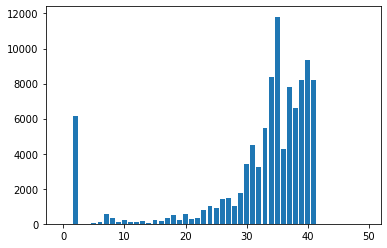

In [6]:
# Create a histogram of the frequency of qualities
import matplotlib.pyplot as plt
%matplotlib inline
def createHist(qualities):
    hist = [0] * 50
    for qual in qualities:
        for phred in qual:
            q = phred33ToQ(phred)
            hist[q] += 1
    return hist
h = createHist(quals)
plt.bar(range(len(h)), h)
plt.show()